<a href="https://colab.research.google.com/github/MinyaevAndrey/MYPETS/blob/main/metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
import numpy as np

def multi_hot_encode(sequences, num_classes):
    results = np.zeros((len(sequences), num_classes))
    for i, sequence in enumerate(sequences):
        results[i][sequence] = 1.0
    return results

x_train = multi_hot_encode(train_data, num_classes=10000)
x_test = multi_hot_encode(test_data, num_classes=10000)

y_train = train_labels.astype("float32")
y_test = test_labels.astype("float32")

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential(
    [
        # Input(shape=(10000,)),
        Dense(16, activation="relu"),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"), # бинарная классификация
    ]
)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",         # бинарная классификация
    metrics=["accuracy"],
)

In [21]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0
)

##lcurvetools

In [ ]:
!pip install lcurvetools -q

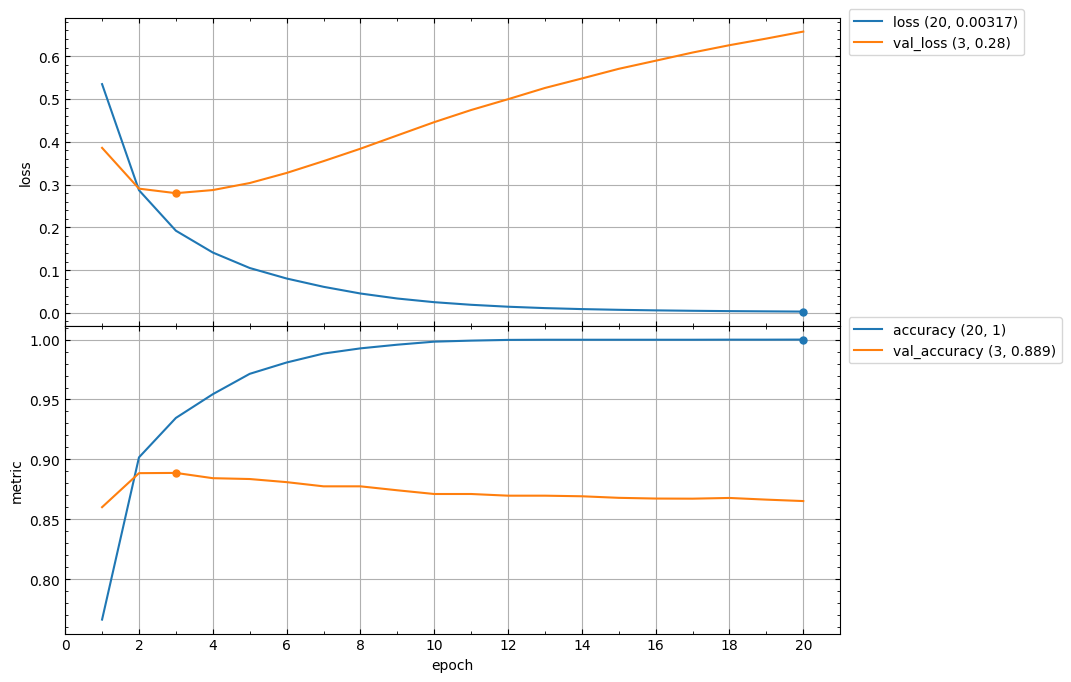

In [ ]:
from lcurvetools import lcurves_by_history
lcurves_by_history(history.history, figsize=(10, 8));

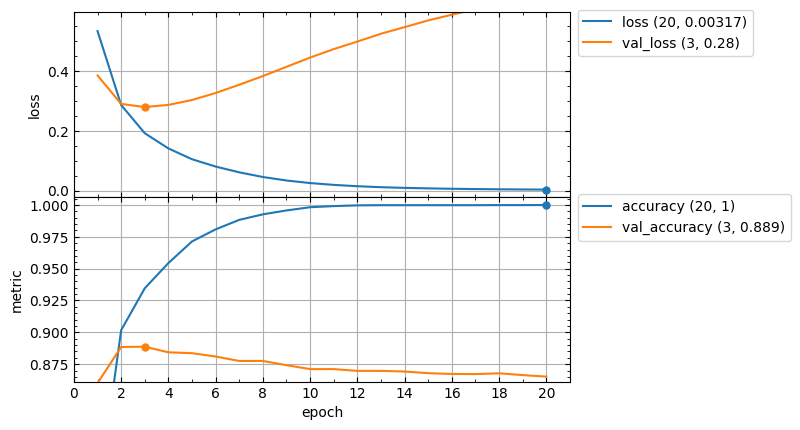

In [ ]:
lcurves_by_history(history.history, epoch_range_to_scale=[5, 15]);

##plot-keras-history

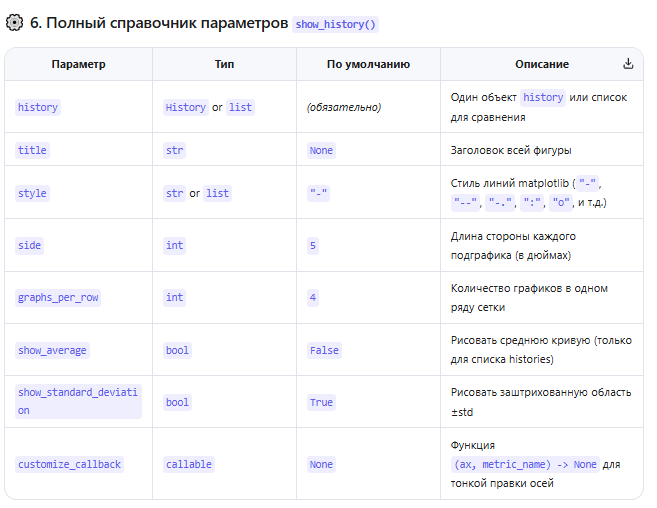

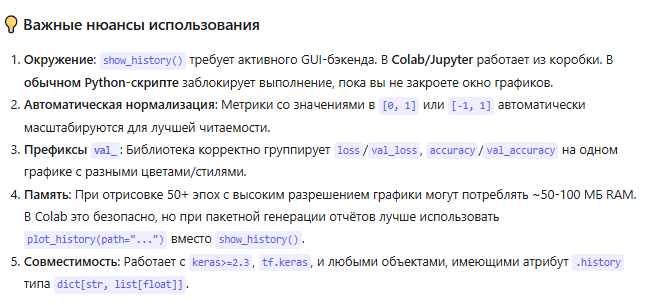

In [22]:
!pip install plot-keras-history -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.4/327.4 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


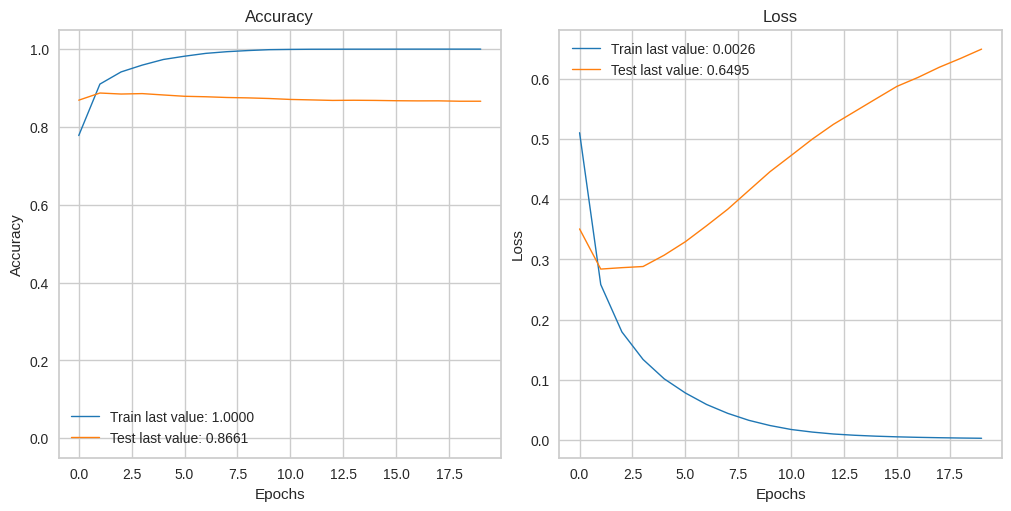

In [23]:
from plot_keras_history import show_history, plot_history
show_history(history)
# plot_history(history, path="training_report.png")  # Сохранит как один большой график

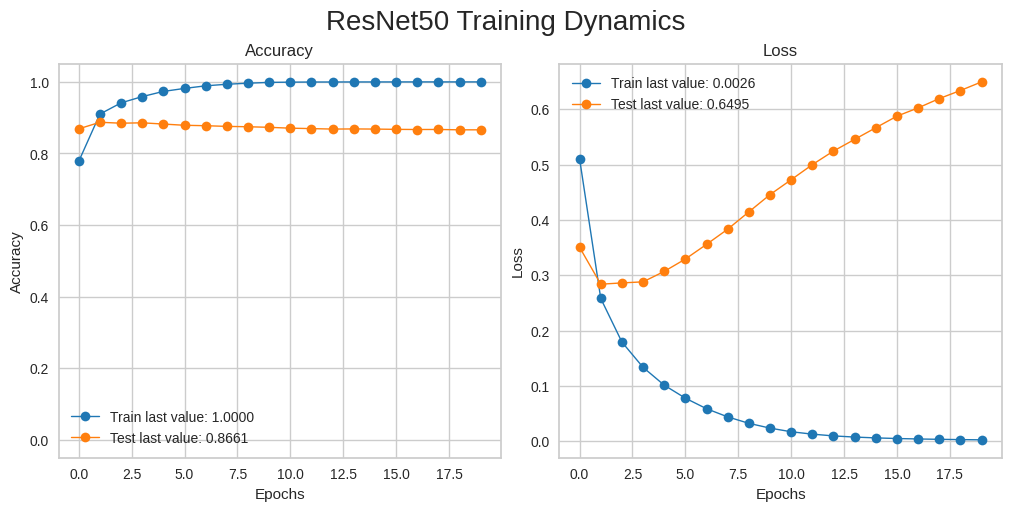

In [26]:
show_history(
    history,
    title="ResNet50 Training Dynamics",
    style="-o",              # Стиль линий matplotlib: сплошная + маркеры
    graphs_per_row=2,        # 2 графика в строке (по умолчанию 4)
    side=5                   # Размер каждого подграфика в дюймах
)

In [ ]:
# # 🔍 3. Сравнение нескольких запусков (holdouts, k-fold, ablation)
# histories = [history_v1, history_v2, history_v3]  # список History-объектов

# show_history(
#     histories,
#     title="Learning Rate Sweep Comparison",
#     style=["-", "--", "-."], # Разные стили для каждого run
#     show_average=True,       # Добавить усреднённую кривую
#     show_standard_deviation=True # Показать область ±std
# )
# # Графики наложатся друг на друга для удобного сравнения динамики

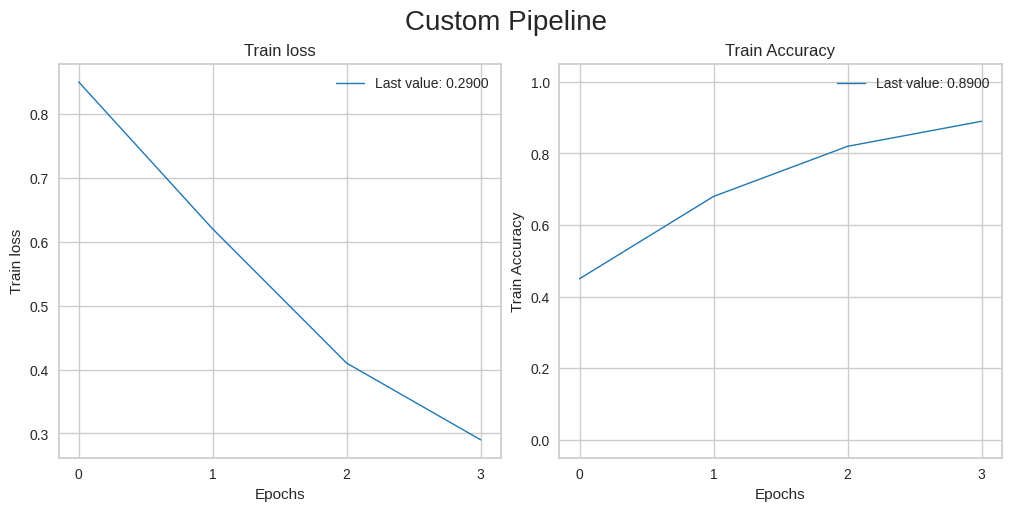

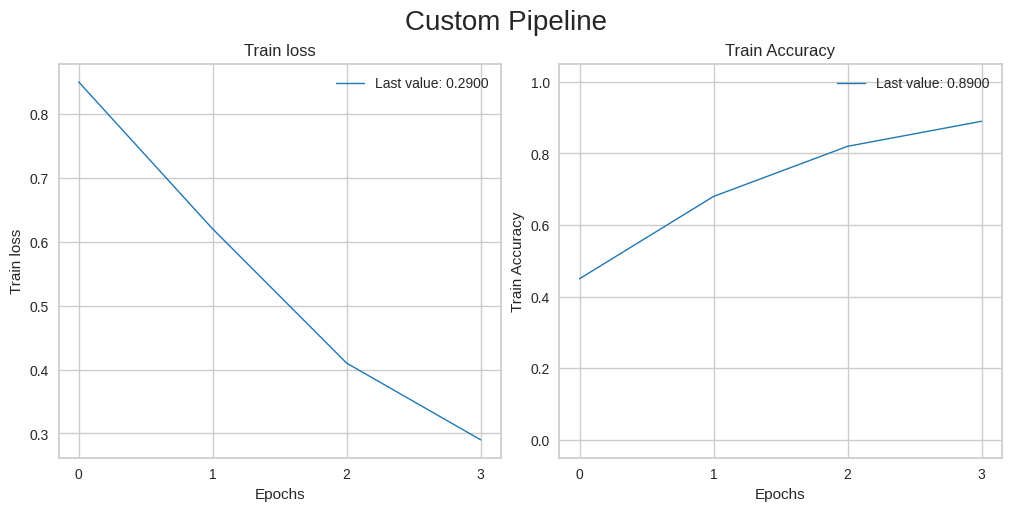

In [28]:
import pandas as pd
from plot_keras_history import show_history

my_metrics = {
    "train_loss": [0.85, 0.62, 0.41, 0.29],
    "val_loss":   [0.91, 0.70, 0.55, 0.48],
    "train_acc":  [0.45, 0.68, 0.82, 0.89],
    "val_acc":    [0.41, 0.65, 0.79, 0.85]
}

# Вариант 1: прямой dict (работает в v2+)
show_history(my_metrics, title="Custom Pipeline")

# Вариант 2: DataFrame (самый надежный, гарантированно работает)
show_history(pd.DataFrame(my_metrics), title="Custom Pipeline")

##gradio plotly

In [ ]:
!pip install gradio plotly -q

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 🎛️ НАСТРОЙКИ
CONFIG = {
    "col_width": 550,              # ширина одной колонки
    "plot_height": 380,            # общая высота фигуры
    "margin": {"l": 50, "r": 40, "t": 60, "b": 40},
}

def plot_history(history, config=None, title="📊 Training Metrics"):
    """Строит интерактивные графики в сетке 1 строка × 2 колонки"""
    if config is None:
        config = CONFIG

    # Находим основные метрики (без val_)
    metrics = [m for m in history.history.keys() if not m.startswith('val_')]
    # Берём ровно 2 метрики для размещения в 1 строку (обычно loss и accuracy)
    metrics_to_plot = metrics[:2]

    # Создаём сетку 1x2
    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[m.replace('_', ' ').title() for m in metrics_to_plot],
        horizontal_spacing=0.12,
        shared_xaxes=True  # Синхронизируем масштаб по эпохам при зуме
    )

    for i, m in enumerate(metrics_to_plot, 1):
        # Train линия
        fig.add_trace(go.Scatter(
            y=history.history[m],
            name=f"Train {m}",
            mode='lines+markers',
            line=dict(width=2)
        ), row=1, col=i)

        # Validation линия (если есть)
        val_m = f'val_{m}'
        if val_m in history.history:
            fig.add_trace(go.Scatter(
                y=history.history[val_m],
                name=f"Val {m}",
                mode='lines+markers',
                line=dict(width=2, dash='dot')
            ), row=1, col=i)

    # Применяем настройки макета
    fig.update_layout(
        width=len(metrics_to_plot) * config["col_width"],
        height=config["plot_height"],
        margin=config["margin"],
        hovermode='x unified',
        title=title,
        template='plotly_white'
    )

    fig.show()

# Рисуем!
plot_history(history)

In [ ]:
from IPython.display import clear_output
import plotly.graph_objects as go
from tensorflow.keras.callbacks import Callback

CONFIG = {
    "col_width": 700,              # ширина одной колонки
    "plot_height": 500,            # общая высота фигуры
    "margin": {"l": 50, "r": 40, "t": 60, "b": 40},
}

class LivePlotCallback(Callback):
    def __init__(self, num_epochs_show=5):
        super().__init__()
        self.num_epochs_show = num_epochs_show
        self.history = {'epoch': []}
        self.total_epochs = None

    def on_train_begin(self, logs=None):
        # Keras передаёт параметры обучения в self.params
        self.total_epochs = self.params.get('epochs', float('inf'))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current_epoch = epoch + 1
        self.history['epoch'].append(current_epoch)

        # 1. Динамически сохраняем ВСЕ пришедшие метрики
        for k, v in logs.items():
            if k not in self.history:
                self.history[k] = []
            self.history[k].append(v)

        # 2. Проверяем, пора ли обновлять график
        should_update = (current_epoch % self.num_epochs_show == 0) or \
                        (current_epoch == self.total_epochs)

        if should_update:
            self._render_plot()

    def _render_plot(self):
        clear_output(wait=True)
        fig = go.Figure()

        # 3. Автоматически находим базовые имена метрик (убираем 'val_')
        all_metrics = [m for m in self.history.keys() if m != 'epoch']
        base_metrics = sorted(list(set(m.replace('val_', '') for m in all_metrics)))

        for base in base_metrics:
            train_key = base
            val_key = f'val_{base}'

            # Train линия
            if train_key in self.history:
                fig.add_trace(go.Scatter(
                    x=self.history['epoch'],
                    y=self.history[train_key],
                    name=train_key,
                    mode='lines+markers',
                    marker=dict(size=6)
                ))

            # Val линия (пунктир)
            if val_key in self.history:
                fig.add_trace(go.Scatter(
                    x=self.history['epoch'],
                    y=self.history[val_key],
                    name=val_key,
                    mode='lines+markers',
                    line=dict(dash='dot'),
                    marker=dict(size=6)
                ))

        # 4. Применяем CONFIG
        fig.update_layout(
            width=CONFIG['col_width'],
            height=CONFIG['plot_height'],
            margin=CONFIG['margin'],
            hovermode='x unified',
            title="🔄 Live Training Metrics",
            xaxis_title="Epoch",
            template='plotly_white'
        )
        fig.show()

# === ИСПОЛЬЗОВАНИЕ ===
live_cb = LivePlotCallback(num_epochs_show=5) # Обновлять каждые 5 эпох
history = model.fit(
    partial_x_train, partial_y_train,
    epochs=20, batch_size=512,
    validation_data=(x_val, y_val),
    verbose=0,
    callbacks=[live_cb]
)

##Ручное построенеи

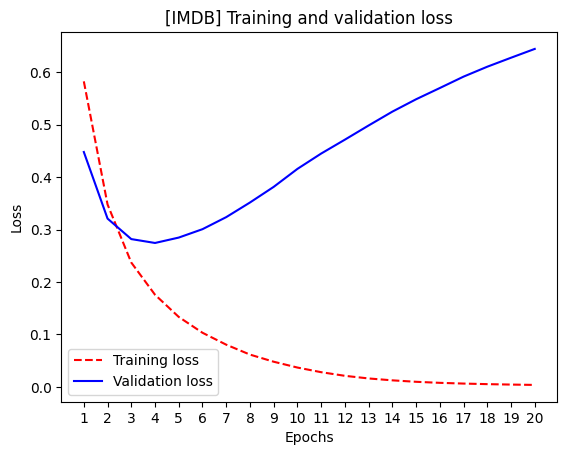

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("[IMDB] Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

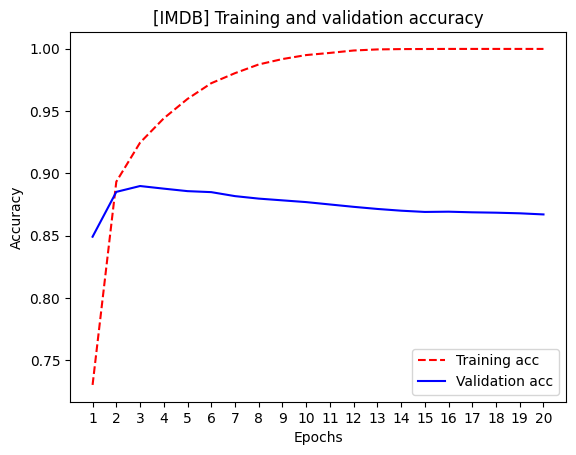

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "r--", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("[IMDB] Training and validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##scikit-plot

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Данные
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Модель
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# 3. Предсказания
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

In [ ]:
!pip install scikit-plot -q

In [ ]:
import numpy as np
import scipy
scipy.interp = np.interp  # Восстанавливаем удалённый алиас
import matplotlib.pyplot as plt
import scikitplot as skplt

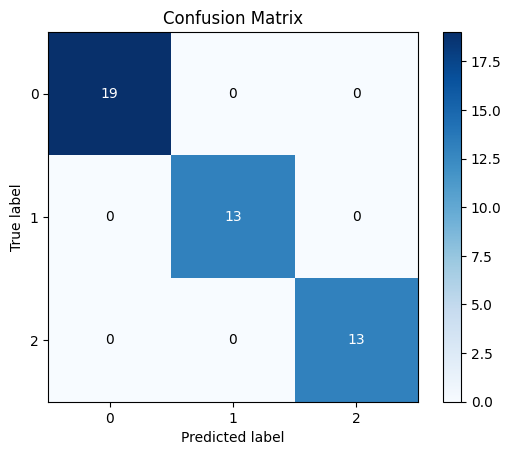

In [ ]:
# 1.1 Матрица ошибок
skplt.metrics.plot_confusion_matrix(y_test, y_pred)
plt.show()

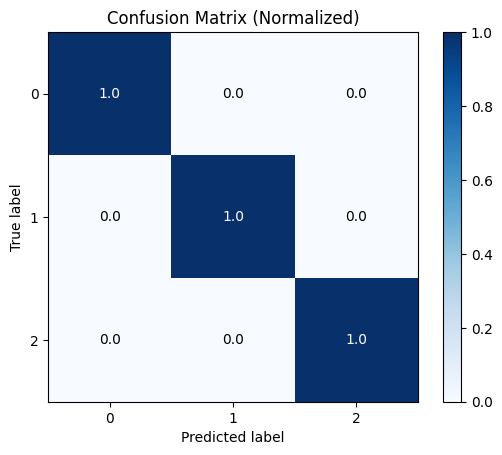

In [ ]:
skplt.metrics.plot_confusion_matrix(y_test, y_pred, normalize=True)
plt.title('Confusion Matrix (Normalized)')
plt.show()

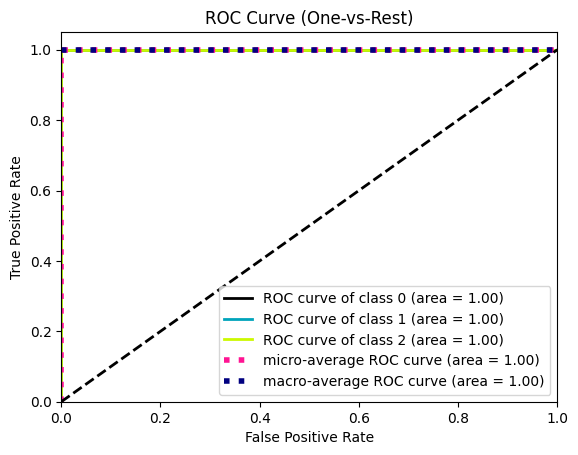

In [ ]:
# 1.2 ROC-кривая (автоматически строит OvR для многоклассовых задач)
skplt.metrics.plot_roc(y_test, y_prob)
plt.title('ROC Curve (One-vs-Rest)')
plt.show()

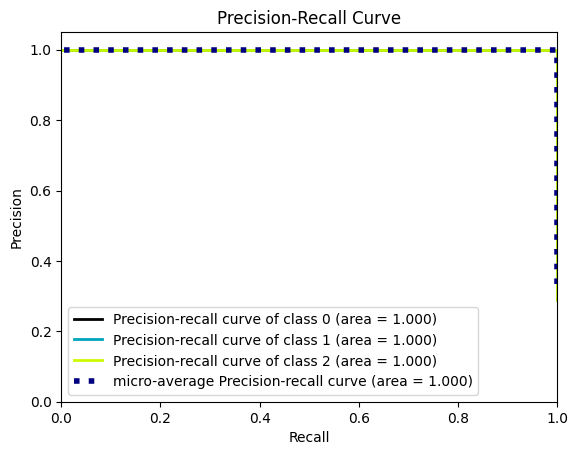

In [ ]:
# 1.3 Precision-Recall Curve
skplt.metrics.plot_precision_recall(y_test, y_prob)
plt.title('Precision-Recall Curve')
plt.show()

In [ ]:
# # 1.4 KS-Statistic (Kolmogorov-Smirnov)
# skplt.metrics.plot_ks_statistic(y_test, y_prob)
# plt.title('KS Statistic')
# plt.show()

In [ ]:
# # 1.5 Cumulative Gain & Lift Curve (оценка качества ранжирования)
# skplt.metrics.plot_cumulative_gain(y_test, y_prob)
# plt.title('Cumulative Gain Chart')
# plt.show()

In [ ]:
# skplt.metrics.plot_lift_curve(y_test, y_prob)
# plt.title('Lift Chart')
# plt.show()

In [ ]:
# # 1.6 Calibration Curve (калибровка вероятностей)
# # Принимает список кортежей: [(название_модели, вероятности), ...]
# skplt.metrics.plot_calibration_curve(y_test, [('RandomForest', y_prob)], n_bins=5)
# plt.title('Calibration Curve')
# plt.show()

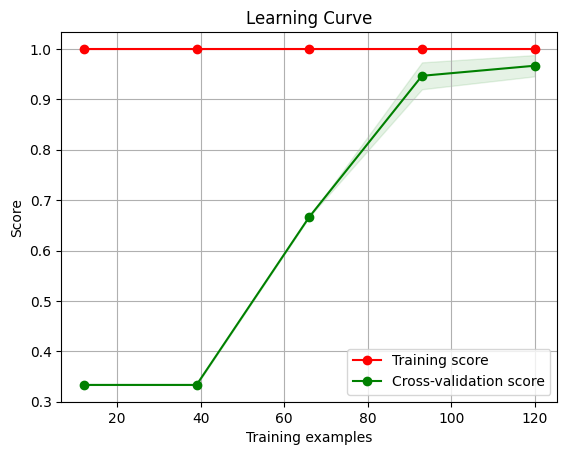

In [ ]:
# 2.1 Кривая обучения (требует сырые X, y и делает кросс-валидацию внутри)
skplt.estimators.plot_learning_curve(clf, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 5))
plt.title('Learning Curve')
plt.show()

##sklearn

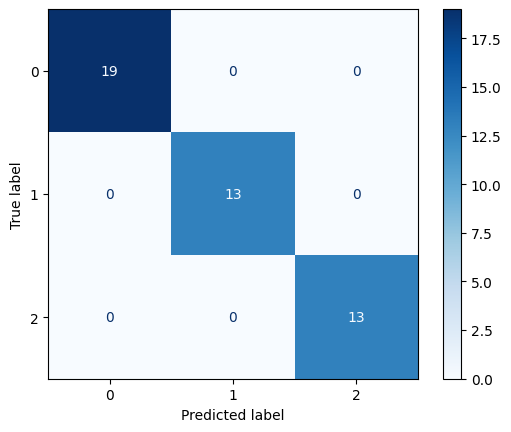

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# 📦 УСТАНОВКА (если нужно)
# ─────────────────────────────────────────────────────────────
# pip install scikit-learn matplotlib seaborn joblib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, RocCurveDisplay,
    precision_recall_curve, average_precision_score, PrecisionRecallDisplay,
    silhouette_score, silhouette_samples
)
from sklearn.calibration import calibration_curve, CalibrationDisplay  # ← исправленный импорт
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans

# Настройки отображения
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# ─────────────────────────────────────────────────────────────
# 🗂️ ПОДГОТОВКА ДАННЫХ
# ─────────────────────────────────────────────────────────────
X, y = load_iris(return_X_y=True)
target_names = load_iris().target_names
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_score = clf.predict_proba(X_test)  # Вероятности по всем 3 классам

In [ ]:
unique, counts = np.unique(y, return_counts=True)
unique

array([0, 1, 2])

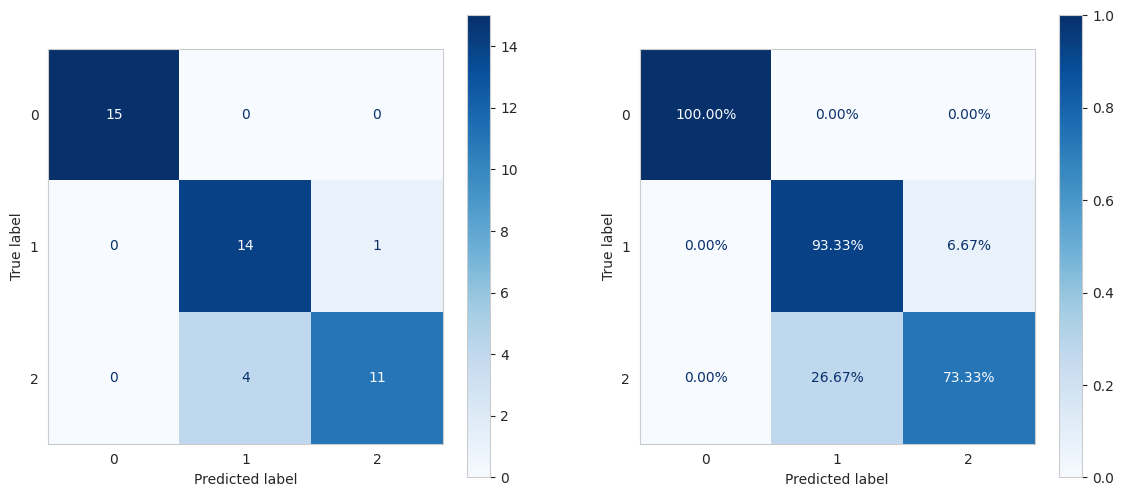

In [ ]:
# 1. Confusion Matrix (Матрица ошибок)

# Создание subplot с 1 строкой и 2 колонками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Первый график (без нормализации)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap='Blues',
    ax=ax1  # указываем ось
)
# ax1.set_title('Confusion Matrix')
ax1.grid(False)  # убираем сетку

# Второй график (с нормализацией)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    normalize='true',
    cmap='Blues',
    values_format='.2%',
    ax=ax2  # указываем ось
)
# ax2.set_title('Normalized Confusion Matrix')
ax2.grid(False)  # убираем сетку

# Настройка общего вида
# plt.tight_layout()  # автоматически подгоняет отступы
plt.show()

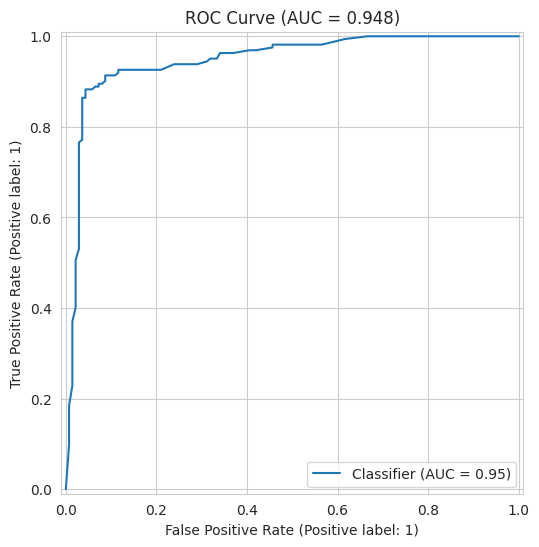

In [ ]:
#  2. ROC Curve (для бинарной и многоклассовой классификации)
# Бинарная классификация

# Создаём бинарный датасет
X_bin, y_bin = make_classification(n_samples=1000, n_classes=2, random_state=42)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_bin, y_bin, test_size=0.3)

clf_bin = RandomForestClassifier(random_state=42)
clf_bin.fit(Xb_tr, yb_tr)
y_score = clf_bin.predict_proba(Xb_te)[:, 1]  # Вероятности для класса 1

# ROC + AUC
RocCurveDisplay.from_predictions(yb_te, y_score)
plt.title(f'ROC Curve (AUC = {roc_auc_score(yb_te, y_score):.3f})')
plt.show()

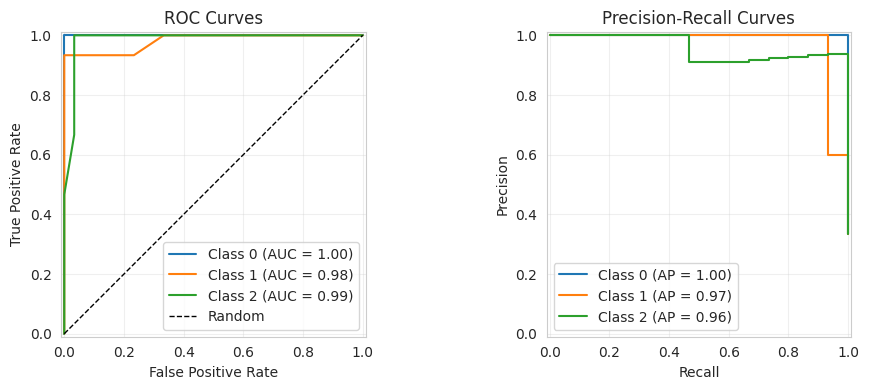

In [ ]:
#  2. ROC Curve (для бинарной и многоклассовой классификации)
# Многоклассовая (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Создаем два подграфика
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(10, 4))

# ROC кривая
for i in range(n_classes):
    RocCurveDisplay.from_predictions(y_test_bin[:, i], y_score[:, i],
                                     name=f'Class {i}', ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves')
ax_roc.legend()
ax_roc.grid(True, alpha=0.3)

# Precision-Recall кривая
for i in range(n_classes):
    PrecisionRecallDisplay.from_predictions(y_test_bin[:, i], y_score[:, i],
                                            name=f'Class {i}', ax=ax_pr)
ax_pr.set_xlabel('Recall')
ax_pr.set_ylabel('Precision')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.legend()
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# # Бинарный случай
# PrecisionRecallDisplay.from_predictions(yb_te, y_score)
# plt.title(f'PR Curve (AP = {average_precision_score(yb_te, y_score):.3f})')
# plt.show()

# # 🔹 Многоклассовая: строим для каждого класса отдельно
# plt.figure()
# for i in range(n_classes):
#     PrecisionRecallDisplay.from_predictions(
#         y_bin_iris[:, i], y_score_iris[:, i], name=f'Class {i}'
#     )
# plt.title('Multiclass Precision-Recall')
# plt.show()

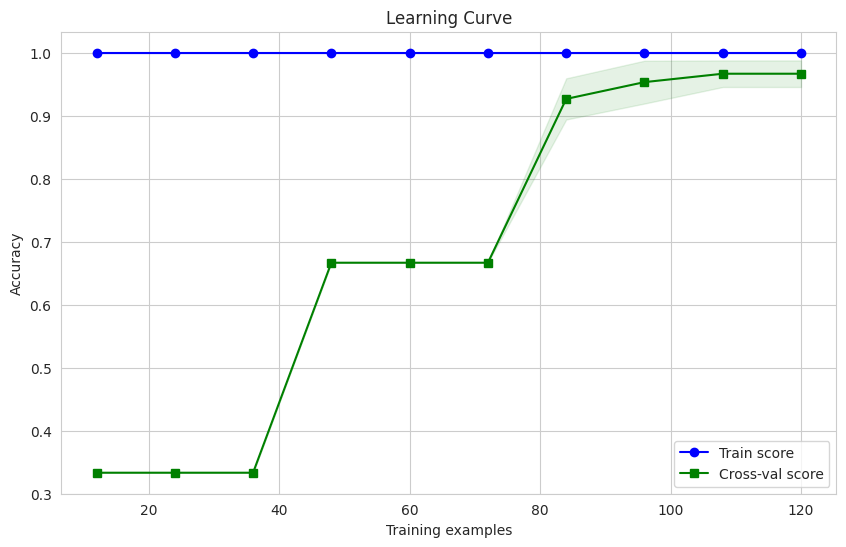

In [ ]:
# 📉 4. Learning Curve (Кривая обучения)
train_sizes, train_scores, test_scores = learning_curve(
    clf, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, 'o-', label='Train score', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 's-', label='Cross-val score', color='green')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')

plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

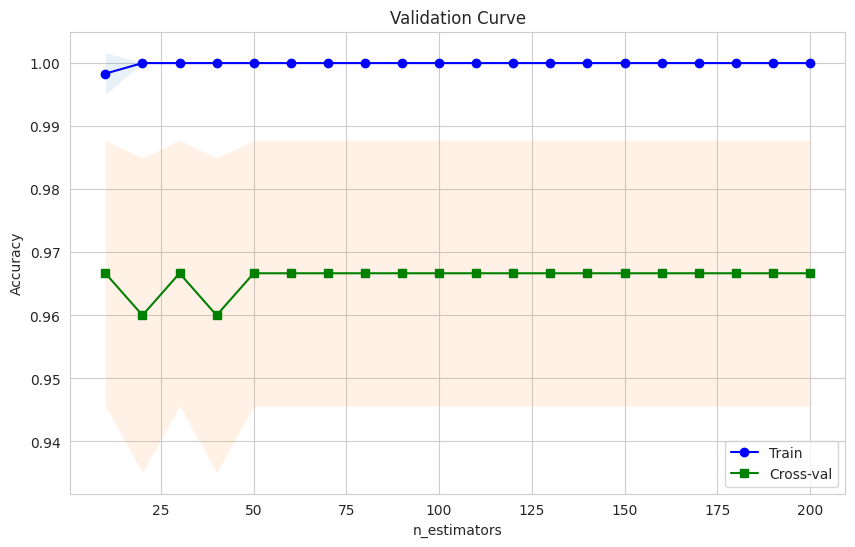

In [ ]:
# ⚙️ 5. Validation Curve (Валидация гиперпараметра)
# Валидация по параметру n_estimators
param_range = np.arange(10, 201, 10)
train_scores, test_scores = validation_curve(
    RandomForestClassifier(random_state=42),
    X, y,
    param_name='n_estimators', param_range=param_range,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure()
plt.plot(param_range, train_mean, 'o-', label='Train', color='blue')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.plot(param_range, test_mean, 's-', label='Cross-val', color='green')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1)

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)
plt.show()

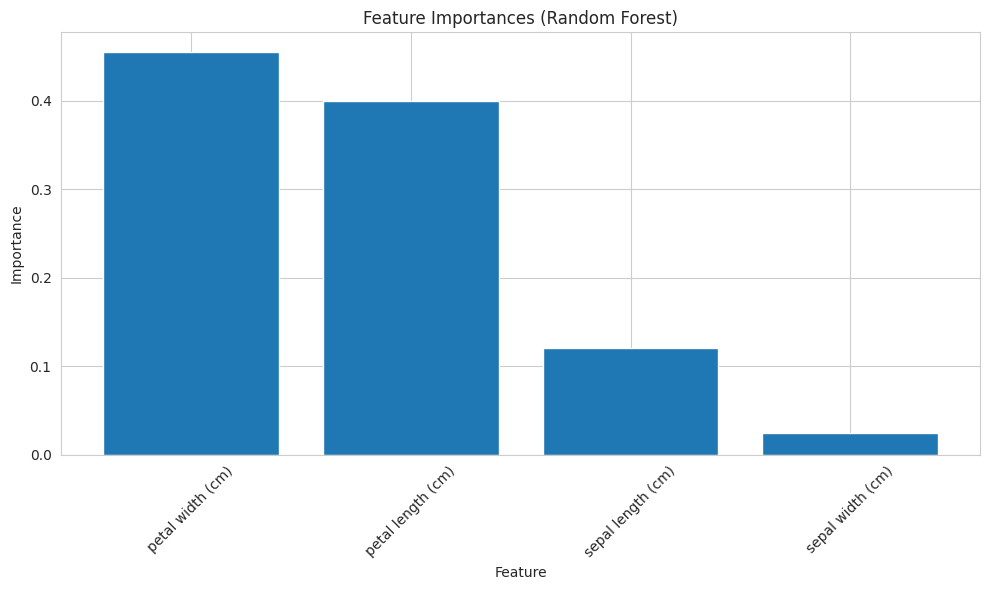

/tmp/ipykernel_8390/383724120.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_result.importances[sorted_idx].T,


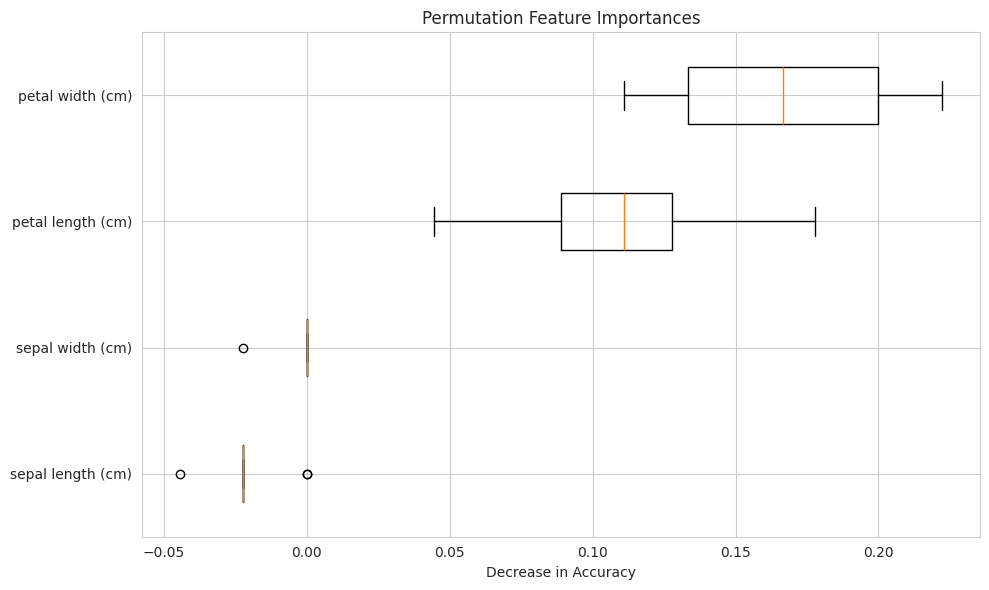

In [ ]:
# 🌲 6. Feature Importances (Важность признаков)
# Через встроенный атрибут модели
importances = clf.feature_importances_
feature_names = load_iris().feature_names
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title('Feature Importances (Random Forest)')
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

# 🔹 Permutation Importance (более надёжный способ)
perm_result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_result.importances_mean.argsort()

plt.figure()
plt.boxplot(perm_result.importances[sorted_idx].T,
            labels=[feature_names[i] for i in sorted_idx], vert=False)
plt.title('Permutation Feature Importances')
plt.xlabel('Decrease in Accuracy')
plt.tight_layout()
plt.show()

##yellowbrick

In [3]:
!pip install yellowbrick -q

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import yellowbrick.classifier as yc
import yellowbrick.model_selection as ym
import yellowbrick.features as yf
import yellowbrick.target as yt

# ─── Ваши данные и разбиение ───
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Функция для создания свежей модели (чтобы визуализаторы не делили состояние)
def get_clf():
    return RandomForestClassifier(random_state=42)

# Хелпер для стандартных визуализаторов (fit + score)
def plot_eval(viz, X_tr, y_tr, X_te, y_te, title):
    print(f"\n📊 {title}")
    viz.fit(X_tr, y_tr)
    viz.score(X_te, y_te)
    viz.show()

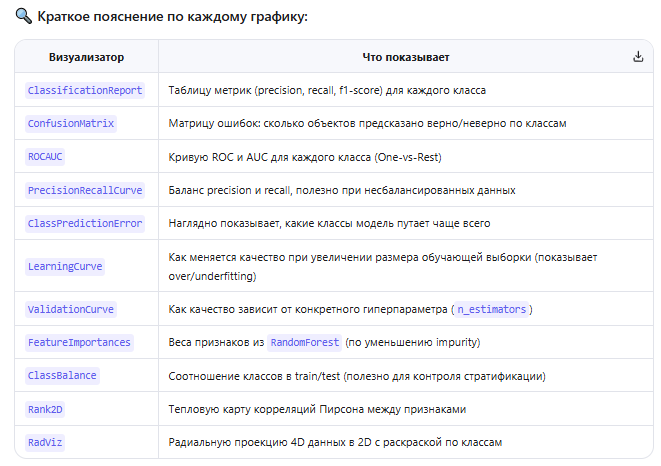

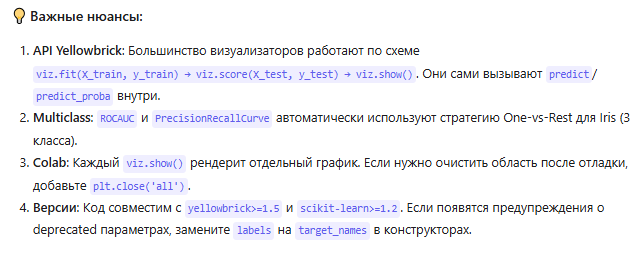


📊 Classification Report


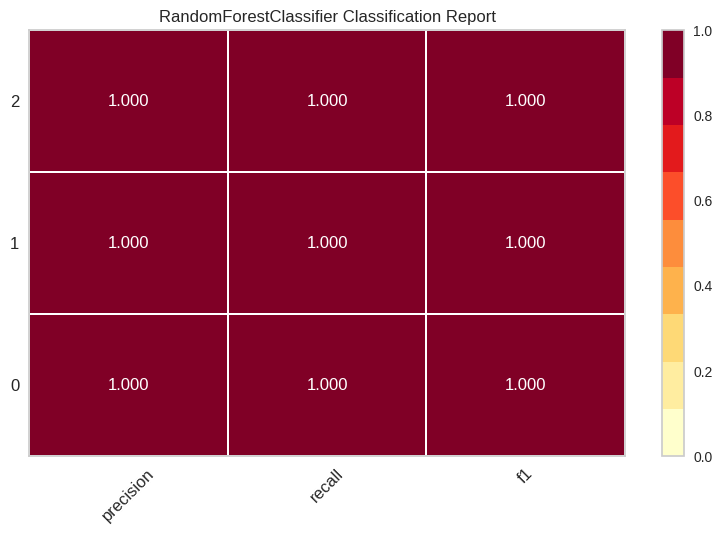

In [5]:
# ═══════════════════════════════════════════════════════════
# 📈 ГРУППА 1: Оценка качества классификации
# ═══════════════════════════════════════════════════════════

# 1. Classification Report (Precision, Recall, F1, Support)
plot_eval(yc.ClassificationReport(get_clf(), labels=class_names),
          X_train, y_train, X_test, y_test,
          "Classification Report"
)


📊 Confusion Matrix


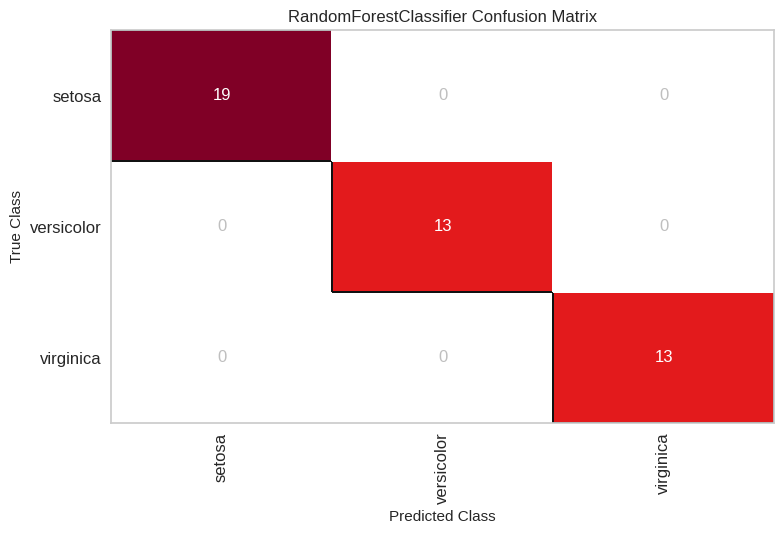

In [8]:
# 2. Confusion Matrix (Матрица ошибок)
plot_eval(yc.ConfusionMatrix(get_clf(), classes=class_names),
          X_train, y_train, X_test, y_test,
          "Confusion Matrix"
)


📊 ROC AUC Curve


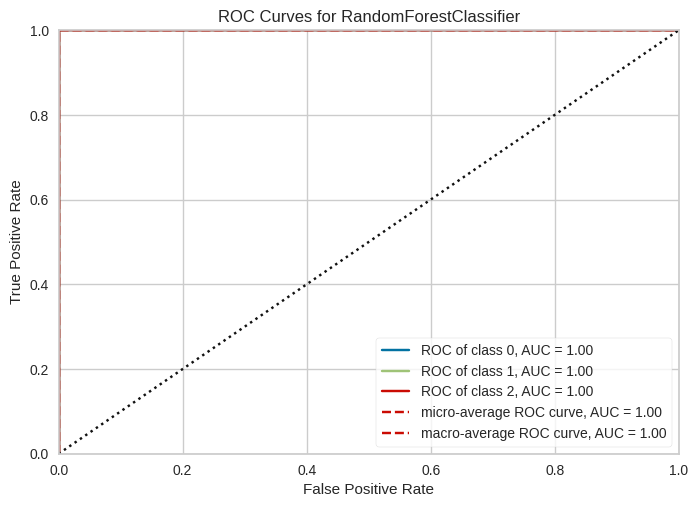

In [9]:
# 3. ROC AUC (Кривая ROC и площадь под ней)
plot_eval(yc.ROCAUC(get_clf()),
          X_train, y_train, X_test, y_test, "ROC AUC Curve")


📊 Precision-Recall Curve


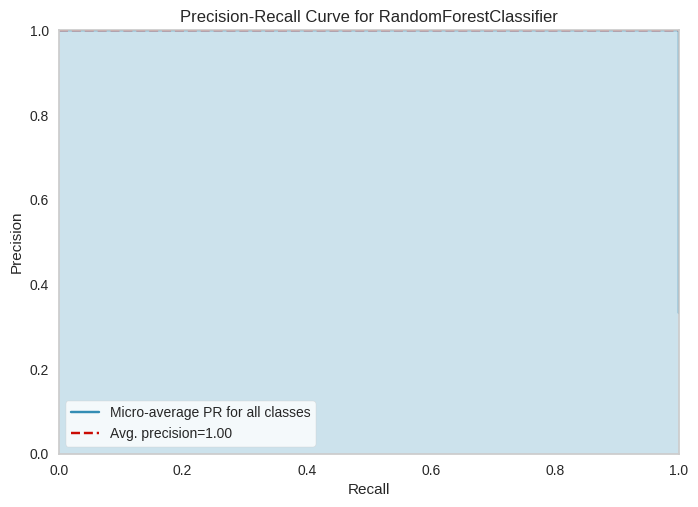

In [10]:
# 4. Precision-Recall Curve (Кривая точности-полноты)
plot_eval(yc.PrecisionRecallCurve(get_clf()),
          X_train, y_train, X_test, y_test, "Precision-Recall Curve")


📊 Class Prediction Error


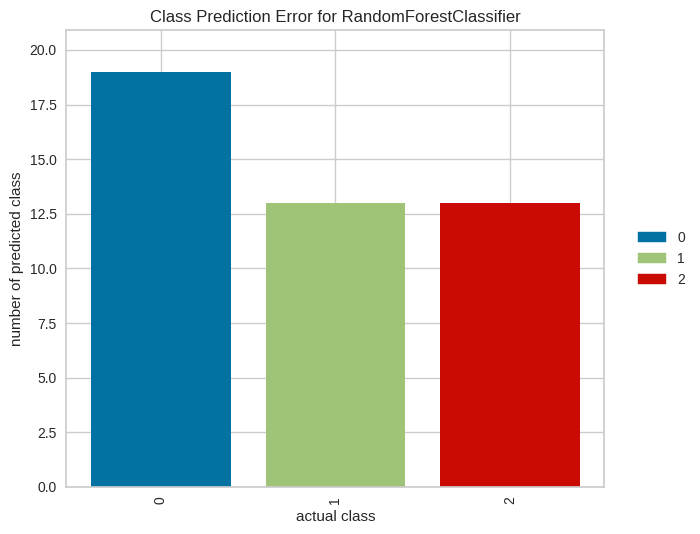

In [11]:
# 5. Class Prediction Error (Ошибки по классам)
plot_eval(yc.ClassPredictionError(get_clf()),
          X_train, y_train, X_test, y_test, "Class Prediction Error")

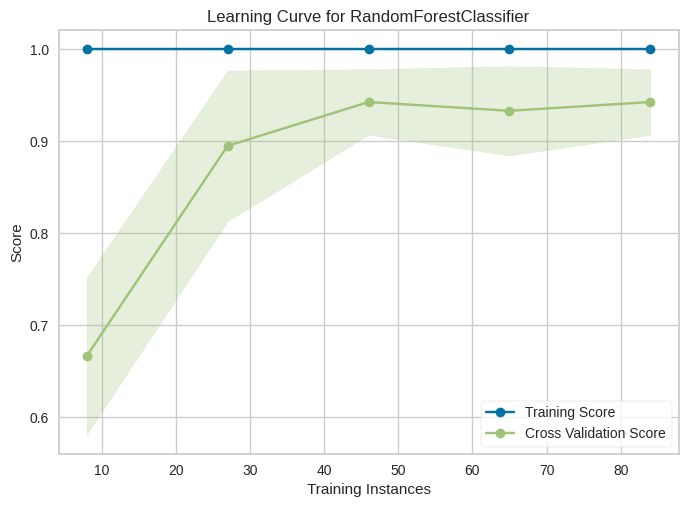

<Axes: title={'center': 'Learning Curve for RandomForestClassifier'}, xlabel='Training Instances', ylabel='Score'>

In [12]:
# ═══════════════════════════════════════════════════════════
# 📉 ГРУППА 2: Диагностика обучения модели
# ═══════════════════════════════════════════════════════════

# 6. Learning Curve (Кривая обучения: train vs val по размеру выборки)
viz_lc = ym.LearningCurve(get_clf(), cv=5, scoring='accuracy')
viz_lc.fit(X_train, y_train)
viz_lc.show()

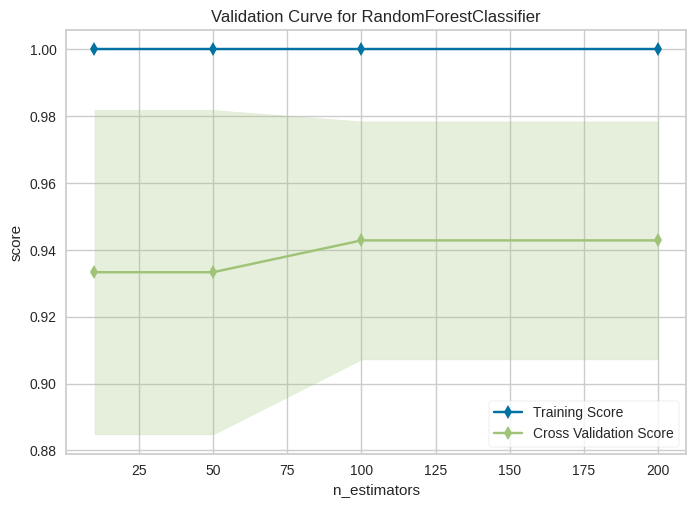

<Axes: title={'center': 'Validation Curve for RandomForestClassifier'}, xlabel='n_estimators', ylabel='score'>

In [13]:
# 7. Validation Curve (Влияние гиперпараметра на качество)
viz_vc = ym.ValidationCurve(get_clf(),
                            param_name='n_estimators',
                            param_range=[10, 50, 100, 200],
                            cv=5, scoring='accuracy')
viz_vc.fit(X_train, y_train)
viz_vc.show()

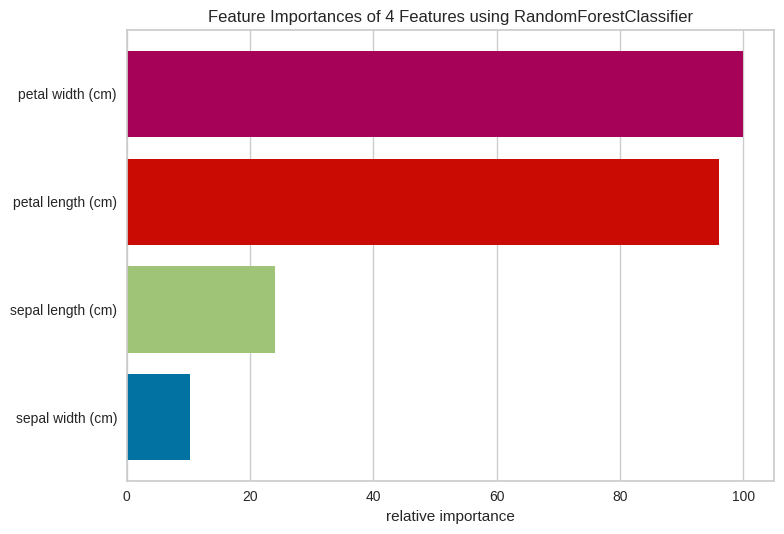

<Axes: title={'center': 'Feature Importances of 4 Features using RandomForestClassifier'}, xlabel='relative importance'>

In [14]:
# ═══════════════════════════════════════════════════════════
# 🧩 ГРУППА 3: Анализ признаков и целевой переменной
# ═══════════════════════════════════════════════════════════

# 8. Feature Importances (Важность признаков для RandomForest)
viz_feat = yf.FeatureImportances(get_clf(), labels=feature_names)
viz_feat.fit(X_train, y_train)
viz_feat.show()

AttributeError: 'ClassBalance' object has no attribute 'score'

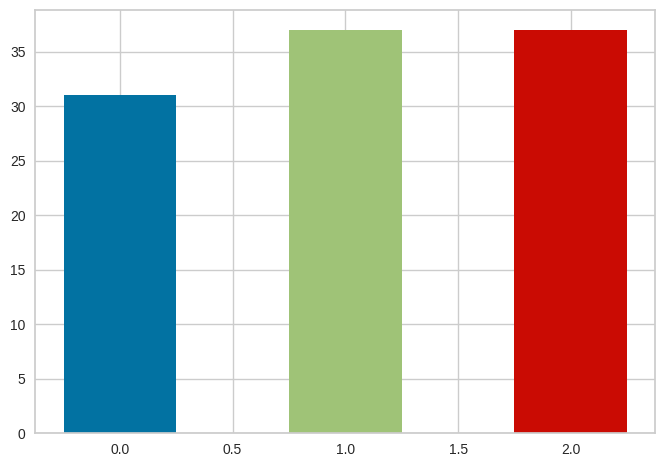

In [15]:
# 9. Class Balance (Распределение классов в train и test)
viz_cb = yt.ClassBalance(labels=class_names)
viz_cb.fit(y_train)
viz_cb.score(y_test)
viz_cb.show()

/usr/local/lib/python3.12/dist-packages/yellowbrick/base.py:236: YellowbrickWarning: Rank2D does not have a reference to a matplotlib.Axes the figure may not render as expected!
  warnings.warn(


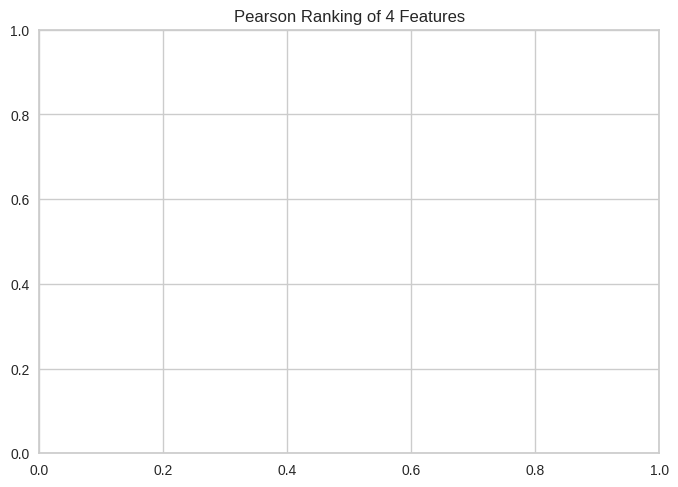

<Axes: title={'center': 'Pearson Ranking of 4 Features'}>

In [16]:
# 10. Rank2D (Попарная корреляция признаков)
viz_r2d = yf.Rank2D(features=feature_names, algorithm='pearson')
viz_r2d.fit(X_train)
viz_r2d.show()

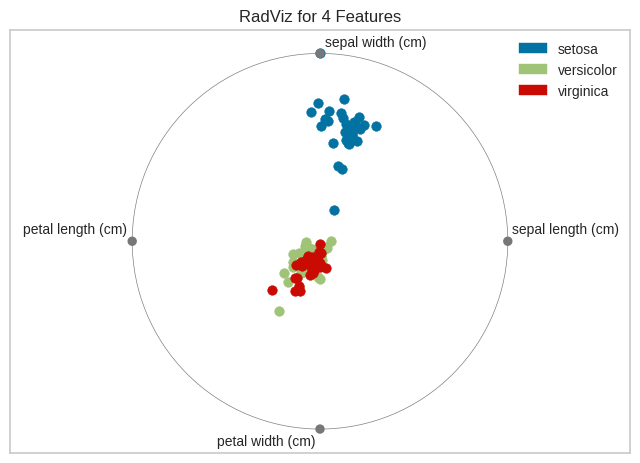

<Axes: title={'center': 'RadViz for 4 Features'}>

In [17]:
# 11. RadViz (Радиальная визуализация многомерных данных)
viz_rad = yf.RadViz(features=feature_names, classes=class_names)
viz_rad.fit(X_train, y_train)
viz_rad.show()